# Monte Carlo likelihoods scored in $N$ and $T$ space

Author: Vincent T. Cooper (2026).

This notebook is a standalone comparison of the two likelihoods. The $N$-scored likelihood uses

$$\dot N_{\mathrm{pred}}=\dot F+(\lambda_{\mathrm{2xCO_2}}-\Delta\lambda)\dot T,$$

whereas the $T$-scored likelihood uses

$$\dot T_{\mathrm{pred}}=\frac{\dot N-\dot F}{\lambda_{\mathrm{2xCO_2}}-\Delta\lambda}.$$

All inputs are independent Gaussian distributions; covariance between $\dot N$ and $\dot T$ is intentionally ignored initially and added later.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 2006--2024 inputs: mean and 1-sigma
N_mu, N_sig = 0.45236271230928726, 0.16146898421227077  ## 0.19--0.72 W m-2 decade-1
F_mu, F_sig = 0.6792412527839483, 0.176923134455099    ## 0.39--0.97 W m-2 decade-1
T_mu, T_sig = 0.2973752655079874, 0.07059634070974384  ## 0.18--0.41 K decade-1
dlambda_mu, dlambda_sig = 0.00, 0.30  ## -0.49--0.50 W m-2 K-1
F2x_mu, F2x_sig = 3.93, 0.29      ## 3.45--4.41 W m-2

n_mc = 100_000
n_mc = 1_000_000
rng = np.random.default_rng(123)

lambda_grid = np.linspace(-4.1, 2.1, 1000)
S_grid = np.r_[
    np.linspace(-6.1, -0.05, 500),
    np.nan,  ## break plotted curve at S=0
    np.linspace(0.05, 10.1, 1000),
]

In [5]:
## MC draws
N_draw = rng.normal(N_mu, N_sig, n_mc)
F_draw = rng.normal(F_mu, F_sig, n_mc)
T_draw = rng.normal(T_mu, T_sig, n_mc)
dlambda_draw = rng.normal(dlambda_mu, dlambda_sig, n_mc)
F2x_draw = rng.normal(F2x_mu, F2x_sig, n_mc)


def normal_pdf(x, mean, sigma):
    z = (x - mean) / sigma
    return np.exp(-0.5 * z**2) / (np.sqrt(2.0 * np.pi) * sigma)


def relative_likelihood(values):
    return values / np.nanmax(values)


def monte_carlo_likelihood(grid, space):
    like_N = np.full(grid.size, np.nan)
    like_T = np.full(grid.size, np.nan)

    for i, value in enumerate(grid):
        if not np.isfinite(value):
            continue

        ## F2x is marginalized as a nuisance quantity
        if space == "lambda":
            lambda_draw = value
        else: # space == "S":
            lambda_draw = -F2x_draw / value
        
        lambda_eff = lambda_draw - dlambda_draw

        ## L_N: predict N from draws of F, T, and Delta-lambda, then score N_obs.
        N_pred = F_draw + lambda_eff * T_draw
        like_N[i] = np.mean(normal_pdf(N_mu, N_pred, N_sig))

        ## L_T: predict T from draws of N, F, and Delta-lambda, then score T_obs.
        T_pred = np.full(n_mc, np.nan)
        valid = np.abs(lambda_eff) > 1e-10
        np.divide(
            N_draw - F_draw, lambda_eff,
            out=T_pred, where=valid,
        )
        like_T[i] = np.nanmean(normal_pdf(T_mu, T_pred, T_sig))

    return relative_likelihood(like_N), relative_likelihood(like_T)


like_N_lambda, like_T_lambda = monte_carlo_likelihood(
    lambda_grid, "lambda"
)
like_N_S, like_T_S = monte_carlo_likelihood(S_grid, "S")

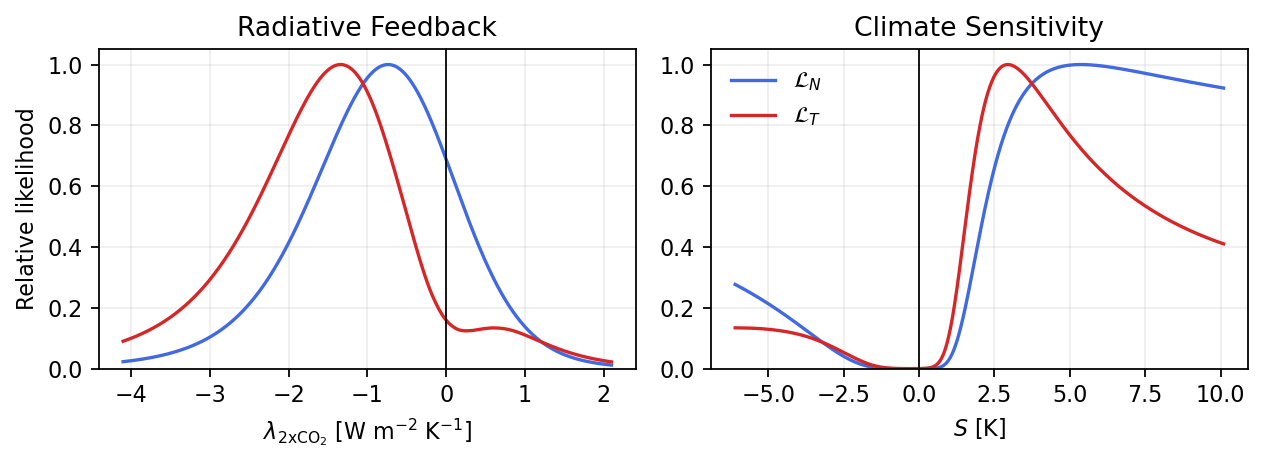

L_N modes: lambda = -0.74, S = 5.4 K
L_T modes: lambda = -1.34, S = 2.9 K


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)

axs[0].plot(lambda_grid, like_N_lambda, color="royalblue", label=r"$\mathcal{L}_N$")
axs[0].plot(lambda_grid, like_T_lambda, color="tab:red", label=r"$\mathcal{L}_T$")
axs[0].axvline(0, color="k", lw=0.8)
axs[0].set_xlabel(r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]")
axs[0].set_ylabel("Relative likelihood")
axs[0].set_title("Radiative Feedback")

axs[1].plot(S_grid, like_N_S, color="royalblue", label=r"$\mathcal{L}_N$")
axs[1].plot(S_grid, like_T_S, color="tab:red", label=r"$\mathcal{L}_T$")
axs[1].axvline(0, color="k", lw=0.8)
axs[1].set_xlabel(r"$S$ [K]")
axs[1].set_title("Climate Sensitivity")
axs[1].legend(frameon=False)

for ax in axs:
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    f"L_N modes: lambda = {lambda_grid[np.nanargmax(like_N_lambda)]:.3f}, "
    f"S = {S_grid[np.nanargmax(like_N_S)]:.1f} K"
)
print(
    f"L_T modes: lambda = {lambda_grid[np.nanargmax(like_T_lambda)]:.3f}, "
    f"S = {S_grid[np.nanargmax(like_T_S)]:.1f} K"
)

## Covariance-aware calculation

This section repeats the calculation accounting for covariance $Cov(\dot T,\dot N)=-0.002970$.

In [9]:
## construct the total N--T covariance.
T_ensemble_sig = 0.007405027792401178
iv_covariance = 0.5 * (
    np.array([[0.074407**2, -0.002356], [-0.002356, 0.131178**2]])
    + np.array([[0.065739**2, -0.003584], [-0.003584, 0.118013**2]])
)
cov_NT = iv_covariance[0, 1]
N_independent_sig = np.sqrt(N_sig**2 - iv_covariance[1, 1])
TN_covariance = np.array([
    [T_ensemble_sig**2 + iv_covariance[0, 0], cov_NT],
    [cov_NT, N_independent_sig**2 + iv_covariance[1, 1]],
])
if np.min(np.linalg.eigvalsh(TN_covariance)) <= 0:
    raise ValueError("must be pos definite")

## MC draws
rng_cov = np.random.default_rng(124)
F2x_draw_cov = rng_cov.normal(F2x_mu, F2x_sig, n_mc)
F_draw_cov = rng_cov.normal(F_mu, F_sig, n_mc)
T_draw_cov = rng_cov.normal(T_mu, T_ensemble_sig, n_mc)
N_draw_cov = rng_cov.normal(N_mu, N_independent_sig, n_mc)
dlambda_draw_cov = rng_cov.normal(dlambda_mu, dlambda_sig, n_mc)
iv_error = rng_cov.multivariate_normal(
    mean=[0.0, 0.0], cov=iv_covariance, size=n_mc
)
T_draw_cov = T_draw_cov + iv_error[:, 0]
N_draw_cov = N_draw_cov + iv_error[:, 1]

## conditional score terms
N_cond_sig = np.sqrt(N_sig**2 - cov_NT**2 / T_sig**2)
T_cond_sig = np.sqrt(T_sig**2 - cov_NT**2 / N_sig**2)
N_adjust = -(cov_NT / T_sig**2) * (T_draw_cov - T_mu)
T_adjust = -(cov_NT / N_sig**2) * (N_draw_cov - N_mu)


def monte_carlo_likelihood_covariance(grid, space):
    like_N = np.full(grid.size, np.nan)
    like_T = np.full(grid.size, np.nan)

    for i, value in enumerate(grid):
        if not np.isfinite(value):
            continue

        if space == "lambda":
            lambda_draw = value
        else: # space == "S":
            lambda_draw = -F2x_draw_cov / value

        lambda_eff = lambda_draw - dlambda_draw_cov

        N_pred = F_draw_cov + lambda_eff * T_draw_cov
        like_N[i] = np.mean(
            normal_pdf(N_mu, N_pred + N_adjust, N_cond_sig)
        )

        T_pred = np.full(n_mc, np.nan)
        valid = np.abs(lambda_eff) > 1e-10
        np.divide(
            N_draw_cov - F_draw_cov, lambda_eff,
            out=T_pred, where=valid,
        )
        like_T[i] = np.nanmean(
            normal_pdf(T_mu, T_pred + T_adjust, T_cond_sig)
        )

    return relative_likelihood(like_N), relative_likelihood(like_T)


like_N_lambda_cov, like_T_lambda_cov = monte_carlo_likelihood_covariance(
    lambda_grid, "lambda"
)
like_N_S_cov, like_T_S_cov = monte_carlo_likelihood_covariance(
    S_grid, "S"
)

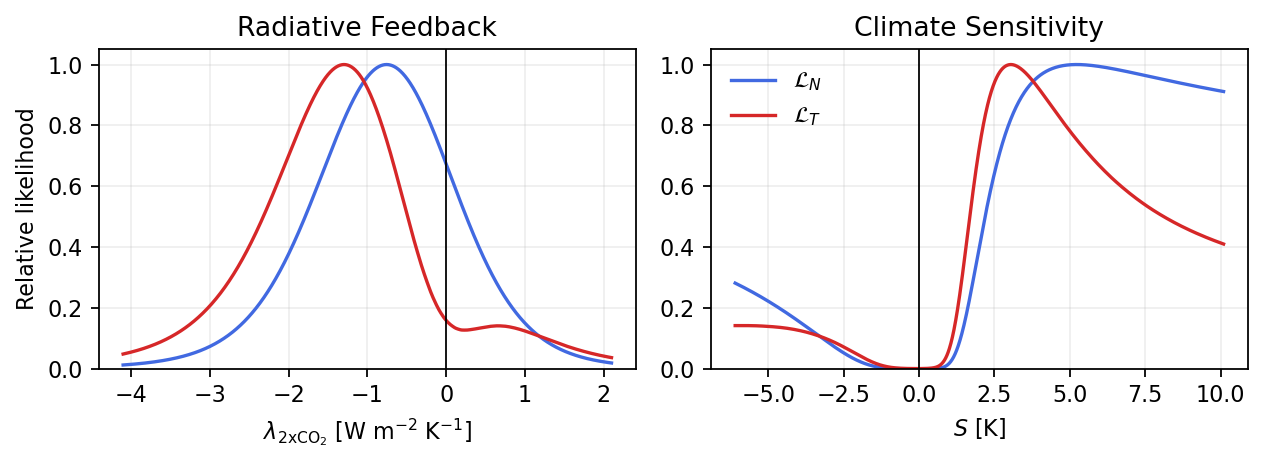

Covariance-aware L_N modes: lambda = -0.755, S = 5.2 K
Covariance-aware L_T modes: lambda = -1.295, S = 3.0 K


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)

axs[0].plot(lambda_grid, like_N_lambda_cov, color="royalblue", label=r"$\mathcal{L}_N$")
axs[0].plot(lambda_grid, like_T_lambda_cov, color="tab:red", label=r"$\mathcal{L}_T$")
axs[0].axvline(0, color="k", lw=0.8)
axs[0].set_xlabel(r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]")
axs[0].set_ylabel("Relative likelihood")
axs[0].set_title("Radiative Feedback")

axs[1].plot(S_grid, like_N_S_cov, color="royalblue", label=r"$\mathcal{L}_N$")
axs[1].plot(S_grid, like_T_S_cov, color="tab:red", label=r"$\mathcal{L}_T$")
axs[1].axvline(0, color="k", lw=0.8)
axs[1].set_xlabel(r"$S$ [K]")
axs[1].set_title("Climate Sensitivity")
axs[1].legend(frameon=False)

for ax in axs:
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    f"Covariance-aware L_N modes: lambda = "
    f"{lambda_grid[np.nanargmax(like_N_lambda_cov)]:.3f}, "
    f"S = {S_grid[np.nanargmax(like_N_S_cov)]:.1f} K"
)
print(
    f"Covariance-aware L_T modes: lambda = "
    f"{lambda_grid[np.nanargmax(like_T_lambda_cov)]:.3f}, "
    f"S = {S_grid[np.nanargmax(like_T_S_cov)]:.1f} K"
)